# 1. Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from IPython.display import HTML
import os

# 2. Chargement et Exploration de dataset df_complet_clean.csv 

In [3]:
folder_path = "VF_Dataset"
df_complet = pd.read_csv(f"{folder_path}/df_complet_clean.csv")

In [4]:
print("Dimensions de dataset complet :", df_complet.shape)
print("Nombre de Communes :", df_complet["libelle_commune"].nunique())

Dimensions de dataset complet : (1845, 87)
Nombre de Communes : 123


In [5]:
HTML("""
<div style="overflow:auto; width:100%; height:300px; border:1px solid black">
{}
</div>
""".format(df_complet.to_html()))

,code_postal,code_commune,libelle_commune,code_departement,libelle_departement,revenu_median_menages_2021,taux_pauvrete_total_2021,taux_pauvrete_0_14_ans,taux_pauvrete_15_29_ans,taux_pauvrete_30_44_ans,taux_pauvrete_45_59_ans,taux_pauvrete_60_74_ans,taux_pauvrete_75_ans_plus,revenu_decile_1_menages,revenu_decile_9_menages,part_revenus_activite,part_revenus_patrimoine,part_prestations_familiales,part_prestations_sociales,part_aides_logement,population_totale_2022,population_0_14_ans,population_15_29_ans,population_30_44_ans,population_45_59_ans,population_60_74_ans,population_75_89_ans,population_90_ans_plus,population_hommes,population_femmes,hommes_0_19_ans,hommes_20_64_ans,hommes_65_ans_plus,femmes_0_19_ans,femmes_20_64_ans,femmes_65_ans_plus,chomeurs_15_24_ans,chomeurs_25_54_ans,chomeurs_55_64_ans,actifs_15_24_ans,actifs_25_54_ans,actifs_55_64_ans,actifs_15_ans_plus,actifs_occupes_15_24_ans,actifs_occupes_25_54_ans,actifs_occupes_55_64_ans,actifs_occupes_15_ans_plus,nombre_salaries,nombre_non_salaries,emplois_salaries,emplois_non_salaries,nombre_creations_entreprises_2024,nombre_total_etablissements_2023,etablissements_industrie,etablissements_construction,etablissements_commerce_services,etablissements_administration_sante_education,effectif_total_salarie_2024,effectif_industrie,effectif_construction,effectif_commerce_services,effectif_administration_sante,residences_principales_hlm,nombre_total_logements,nombre_logements_vacants,taux_cambriolage,taux_violence_famille,taux_violence_sexuelle,taux_vols_armes,nb_associations,total_inscrits,total_abstentions,total_votants,total_blancs,total_nuls,total_exprimes,ratio_abstentions_inscrits,ratio_votants_inscrits,ratio_blancs_votants,ratio_nuls_votants,ratio_exprimes_inscrits,ratio_exprimes_votants,nom_complet,voix,pourcentage_voix,famille_politique,parti_politique
0,92002.0,2,Antony,92,Hauts-de-Seine,32000,9.0,16.0,10.0,9.0,8.0,7.0,6.0,14590.0,57850.0,89.20,4.4,9.20,2.6,0.5,64026.0,11730.068305,11858.906246,13486.105208,12217.409424,9361.167274,4598.218481,774.125061,30783.239280,33242.760720,7880.230179,18202.812016,4700.197085,7920.717611,18922.086672,6399.956437,567.988372,1943.565218,422.464484,2489.211704,24022.890028,5642.063836,32836.813911,1921.223332,22079.324810,5219.599352,29875.383101,26640.218293,3235.164809,19400.514592,2851.132874,1172.0,5402.0,50.0,117.0,1179.0,210.0,21621.0,1343.0,846.0,11204.0,8228.0,4819.037164,30549.154917,2121.678290,8.347203,2.873832,1.108925,0.000000,977,41966.0,8309.0,33657.0,722.0,0.0,32935.0,19.799361,80.200639,2.145170,0.000000,78.480198,97.854830,ARTHAUD Nathalie,95,0.144145,Extrême gauche,Lutte Ouvrière
1,92002.0,2,Antony,92,Hauts-de-Seine,32000,9.0,16.0,10.0,9.0,8.0,7.0,6.0,14590.0,57850.0,89.20,4.4,9.20,2.6,0.5,64026.0,11730.068305,11858.906246,13486.105208,12217.409424,9361.167274,4598.218481,774.125061,30783.239280,33242.760720,7880.230179,18202.812016,4700.197085,7920.717611,18922.086672,6399.956437,567.988372,1943.565218,422.464484,2489.211704,24022.890028,5642.063836,32836.813911,1921.223332,22079.324810,5219.599352,29875.383101,26640.218293,3235.164809,19400.514592,2851.132874,1172.0,5402.0,50.0,117.0,1179.0,210.0,21621.0,1343.0,846.0,11204.0,8228.0,4819.037164,30549.154917,2121.678290,8.347203,2.873832,1.108925,0.000000,977,41966.0,8309.0,33657.0,722.0,0.0,32935.0,19.799361,80.200639,2.145170,0.000000,78.480198,97.854830,abstentions,8309,12.607350,NaN,NaN
2,92002.0,2,Antony,92,Hauts-de-Seine,32000,9.0,16.0,10.0,9.0,8.0,7.0,6.0,14590.0,57850.0,89.20,4.4,9.20,2.6,0.5,64026.0,11730.068305,11858.906246,13486.105208,12217.409424,9361.167274,4598.218481,774.125061,30783.239280,33242.760720,7880.230179,18202.812016,4700.197085,7920.717611,18922.086672,6399.956437,567.988372,1943.565218,422.464484,2489.211704,24022.890028,5642.063836,32836.813911,1921.223332,22079.324810,5219.599352,29875.383101,26640.218293,3235.164809,19400.514592,2851.132874,1172.0,5402.0,50.0,117.0,1179.0,210.0,21621.0,1343.0,846.0,11204.0,8228.0,4819.037164,3054

# 3. Traitement des valeurs NULL ---> NULL to Median

In [6]:
cols_num = df_complet.select_dtypes(
    include=["int64", "float64"]
).columns

for col in cols_num:
    median_value = df_complet[col].median()
    df_complet[col].fillna(median_value, inplace=True)

C:\Users\ZAKARIA\AppData\Local\Temp\ipykernel_5828\74089255.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_complet[col].fillna(median_value, inplace=True)


# 4. Suppression des abstentions, blancs et nuls 

In [7]:
pd.DataFrame(df_complet["nom_complet"].unique(), columns=["nom_complet"])

,nom_complet
0,ARTHAUD Nathalie
1,abstentions
2,MÉLENCHON Jean-Luc
3,blancs
4,ROUSSEL Fabien
5,HIDALGO Anne
6,LASSALLE Jean
7,DUPONT-AIGNAN Nicolas
8,LE PEN Marine
9,PÉCRESSE Valérie


In [8]:
to_remove = ["abstentions", "blancs", "nuls"]

df_complet = df_complet[~df_complet["nom_complet"].isin(to_remove)]

print(df_complet.shape)

(1476, 87)


In [9]:
pd.DataFrame(df_complet["nom_complet"].unique(), columns=["nom_complet"])

,nom_complet
0,ARTHAUD Nathalie
1,MÉLENCHON Jean-Luc
2,ROUSSEL Fabien
3,HIDALGO Anne
4,LASSALLE Jean
5,DUPONT-AIGNAN Nicolas
6,LE PEN Marine
7,PÉCRESSE Valérie
8,ZEMMOUR Éric
9,JADOT Yannick


# 5. Extraction de dataset_Gagnant + Exploration

In [10]:
df_gagnant = df_complet.loc[
    df_complet.groupby("libelle_commune")["voix"].idxmax()
]

In [11]:
folder_path = "VF_Dataset"
os.makedirs(folder_path, exist_ok=True)
df_gagnant.to_csv(f"{folder_path}/df_gagnant.csv", index=False)

In [12]:
print("Dimensions de dataset gagnant :", df_gagnant.shape)
print("Nombre de Communes :", df_gagnant["libelle_commune"].nunique())

Dimensions de dataset gagnant : (123, 87)
Nombre de Communes : 123


In [13]:
HTML("""
<div style="overflow:auto; width:100%; height:300px; border:1px solid black">
{}
</div>
""".format(df_gagnant.to_html()))

,code_postal,code_commune,libelle_commune,code_departement,libelle_departement,revenu_median_menages_2021,taux_pauvrete_total_2021,taux_pauvrete_0_14_ans,taux_pauvrete_15_29_ans,taux_pauvrete_30_44_ans,taux_pauvrete_45_59_ans,taux_pauvrete_60_74_ans,taux_pauvrete_75_ans_plus,revenu_decile_1_menages,revenu_decile_9_menages,part_revenus_activite,part_revenus_patrimoine,part_prestations_familiales,part_prestations_sociales,part_aides_logement,population_totale_2022,population_0_14_ans,population_15_29_ans,population_30_44_ans,population_45_59_ans,population_60_74_ans,population_75_89_ans,population_90_ans_plus,population_hommes,population_femmes,hommes_0_19_ans,hommes_20_64_ans,hommes_65_ans_plus,femmes_0_19_ans,femmes_20_64_ans,femmes_65_ans_plus,chomeurs_15_24_ans,chomeurs_25_54_ans,chomeurs_55_64_ans,actifs_15_24_ans,actifs_25_54_ans,actifs_55_64_ans,actifs_15_ans_plus,actifs_occupes_15_24_ans,actifs_occupes_25_54_ans,actifs_occupes_55_64_ans,actifs_occupes_15_ans_plus,nombre_salaries,nombre_non_salaries,emplois_salaries,emplois_non_salaries,nombre_creations_entreprises_2024,nombre_total_etablissements_2023,etablissements_industrie,etablissements_construction,etablissements_commerce_services,etablissements_administration_sante_education,effectif_total_salarie_2024,effectif_industrie,effectif_construction,effectif_commerce_services,effectif_administration_sante,residences_principales_hlm,nombre_total_logements,nombre_logements_vacants,taux_cambriolage,taux_violence_famille,taux_violence_sexuelle,taux_vols_armes,nb_associations,total_inscrits,total_abstentions,total_votants,total_blancs,total_nuls,total_exprimes,ratio_abstentions_inscrits,ratio_votants_inscrits,ratio_blancs_votants,ratio_nuls_votants,ratio_exprimes_inscrits,ratio_exprimes_votants,nom_complet,voix,pourcentage_voix,famille_politique,parti_politique
1143,94001.0,1,Ablon-sur-Seine,94,Val-de-Marne,24000,15.0,23.0,19.0,17.0,18.0,14.0,14.0,11900.0,41220.0,83.60,3.3,6.80,5.0,0.9,6029.0,1385.293934,1118.171724,1349.047136,1081.738214,631.458765,375.215285,88.074941,2856.253874,3172.746126,897.943772,1634.347911,323.962191,854.729445,1805.974385,512.042296,64.087737,255.984967,31.132625,281.194173,2365.128828,360.304816,3040.481002,217.106436,2109.143861,329.172191,2687.314772,2418.962982,268.351790,456.906385,143.933536,105.0,326.0,3.0,38.0,63.0,14.0,721.0,19.0,143.0,199.0,360.0,285.389087,2658.882936,234.141459,8.274151,2.322110,0.000000,0.000000,99,3121.0,708.0,2413.0,26.0,25.0,2362.0,22.685037,77.314963,1.077497,1.036055,75.680872,97.886448,MÉLENCHON Jean-Luc,655,1.950450,Gauche,La France Insoumise
1156,94002.0,2,Alfortville,94,Val-de-Marne,22360,21.0,23.0,18.0,22.0,22.0,21.0,21.0,10300.0,41600.0,90.00,3.6,5.10,6.7,1.6,45569.0,8108.672880,9022.492367,10775.759586,8317.834718,6014.655657,2899.961163,429.623629,21672.058543,23896.941457,5294.245461,13527.998183,2849.814899,5141.074798,14760.183162,3995.683498,470.069388,2574.236323,357.807613,2138.864450,18185.726022,3556.836056,24272.713907,1668.795063,15611.489700,3199.028442,20822.158489,18564.611621,2257.546867,9997.673559,1846.043705,1092.0,4044.0,59.0,267.0,926.0,98.0,11407.0,834.0,1826.0,6452.0,2295.0,8505.904811,23721.569764,1686.652632,5.648867,4.257280,1.360574,0.109724,883,23940.0,5388.0,18552.0,294.0,113.0,18145.0,22.506266,77.493734,1.584735,0.609099,75.793651,97.806166,MÉLENCHON Jean-Luc,6786,10.296483,Gauche,La France Insoumise
13,92002.0,2,Antony,92,Hauts-de-Seine,32000,9.0,16.0,10.0,9.0,8.0,7.0,6.0,14590.0,57850.0,89.20,4.4,9.20,2.6,0.5,64026.0,11730.068305,11858.906246,13486.105208,12217.409424,9361.167274,4598.218481,774.125061,30783.239280,33242.760720,7880.230179,18202.812016,4700.197085,7920.717611,18922.086672,6399.956437,567.988372,1943.565218,422.464484,2489.211704,24022.890028,5642.063836,32836.813911,1921.223332,22079.324810,5219.599352,29875.383101,26640.218293,3235.164809,19400.514592,2851.132874,1172.0,5402.0,50.0,117.0,1179.0,210.0,21621.0,1343.0,846.0,11204.0,8228.0,4819.037164,30549.1549

# 6. Répartition des familles politiques

In [14]:
print(df_gagnant["famille_politique"].value_counts())

famille_politique
Gauche    69
Centre    54
Name: count, dtype: int64


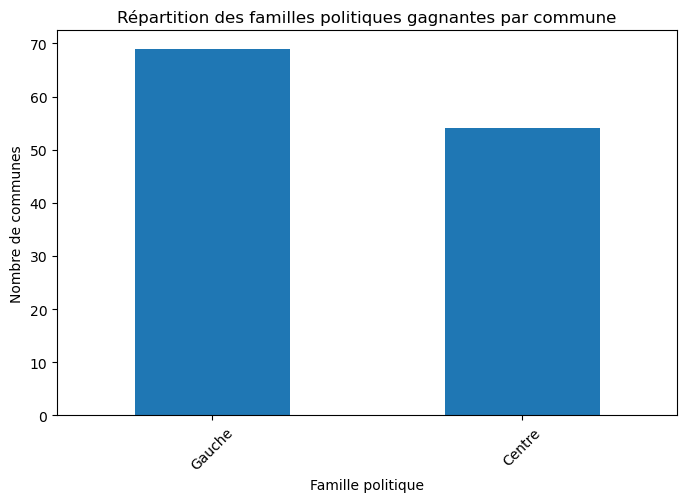

In [15]:
df_gagnant["famille_politique"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Répartition des familles politiques gagnantes par commune"
)

plt.xlabel("Famille politique")
plt.ylabel("Nombre de communes")
plt.xticks(rotation=45)
plt.show()

In [16]:
print(df_complet["famille_politique"].value_counts(dropna=False))

famille_politique
Gauche            492
Extrême gauche    246
Centre            246
Droite            246
Extrême droite    246
Name: count, dtype: int64


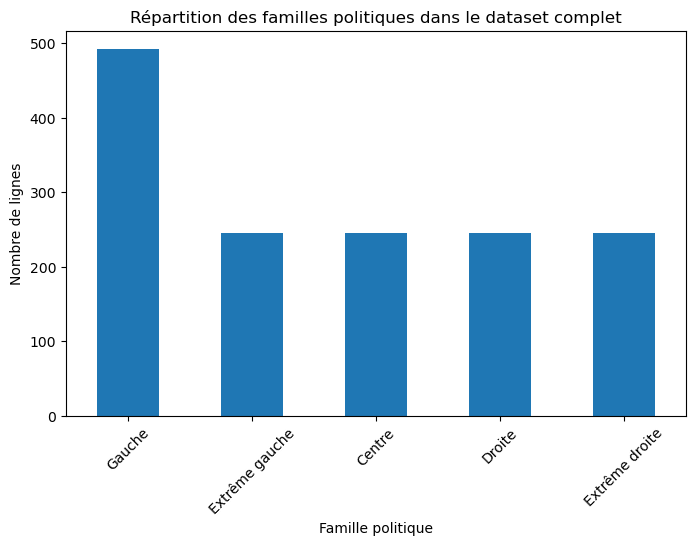

In [17]:
df_complet["famille_politique"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Répartition des familles politiques dans le dataset complet"
)

plt.xlabel("Famille politique")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)

plt.show()

# 7. Distribution de la variable cible (voix) et (log_voix)

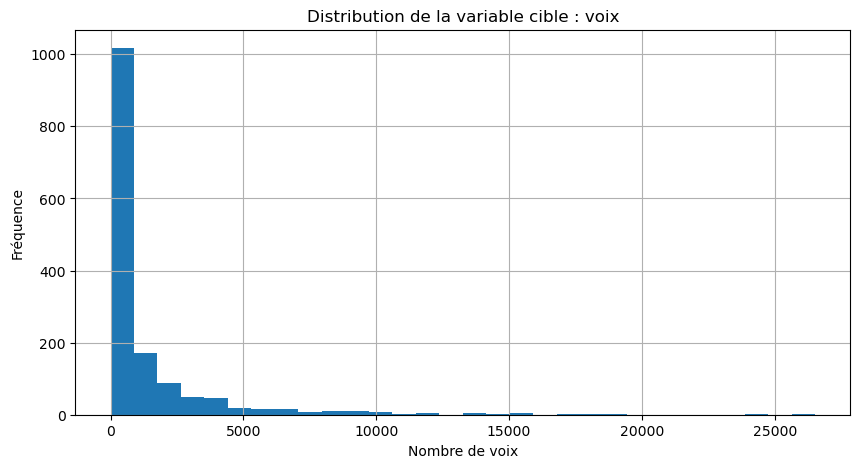

In [18]:
plt.figure(figsize=(10,5))

df_complet["voix"].hist(
    bins=30
)

plt.title("Distribution de la variable cible : voix")

plt.xlabel("Nombre de voix")
plt.ylabel("Fréquence")

plt.show()

### Transformation logarithmique de la cible

In [19]:
df_complet["log_voix"] = np.log1p(df_complet["voix"])

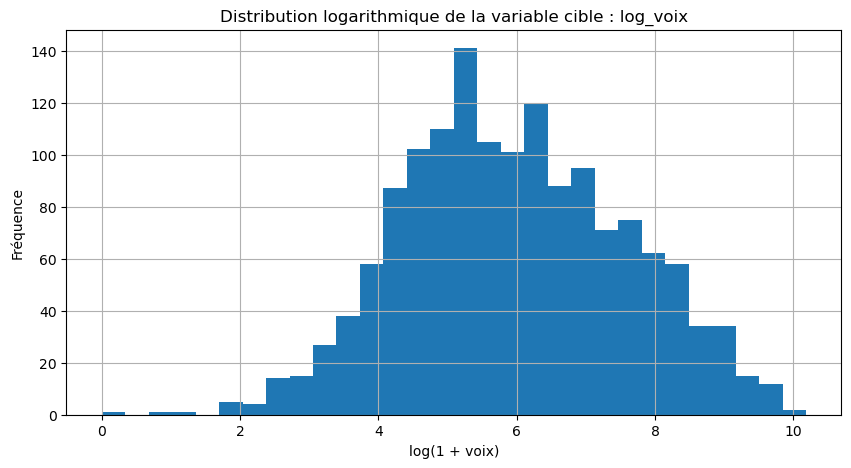

In [20]:
plt.figure(figsize=(10,5))

df_complet["log_voix"].hist(
    bins=30
)

plt.title(
    "Distribution logarithmique de la variable cible : log_voix"
)

plt.xlabel("log(1 + voix)")
plt.ylabel("Fréquence")

plt.show()

distribution plus équilibrée
variance plus stable
réduction impact outliers
meilleure séparation des valeurs
apprentissage ML plus stable

L’analyse initiale de la variable cible voix a montré une forte asymétrie positive ainsi que la présence de valeurs extrêmes importantes.
Afin de réduire l’impact des outliers et de stabiliser la variance des données, une transformation logarithmique log(1 + voix) a été appliquée.
La nouvelle distribution obtenue est beaucoup plus équilibrée et mieux adaptée à l’apprentissage des modèles de Machine Learning.¶

# 8. Création de nouvelles variables intelligentes

In [21]:
df_complet["entreprises_par_habitant"] = (
    df_complet["nombre_total_etablissements_2023"] /
    df_complet["population_totale_2022"]
)
df_complet["entreprises_par_habitant"].describe()

count    1476.000000
mean        0.088906
std         0.033325
min         0.012636
25%         0.068156
50%         0.080963
75%         0.097795
max         0.248345
Name: entreprises_par_habitant, dtype: float64

Le ratio entreprises par habitant permet d’évaluer le niveau d’activité économique des communes.

Les territoires présentant une forte densité d’établissements peuvent présenter des comportements électoraux différents liés à leur attractivité économique et à leur dynamisme local.

In [22]:
df_complet["associations_par_habitant"] = (
    df_complet["nb_associations"] /
    df_complet["population_totale_2022"]
)
df_complet["associations_par_habitant"].describe()

count    1476.000000
mean        0.019731
std         0.006287
min         0.002808
25%         0.016174
50%         0.018143
75%         0.022474
max         0.047980
Name: associations_par_habitant, dtype: float64

Le nombre d’associations rapporté à la population permet d’estimer la dynamique sociale et associative des communes.

Cette variable peut refléter un niveau plus élevé de participation citoyenne et d’engagement local.

In [23]:
df_complet["participation_reelle"] = (
    df_complet["total_votants"] /
    df_complet["total_inscrits"]
)
df_complet["participation_reelle"].describe()

count    1476.000000
mean        0.749669
std         0.054304
min         0.582404
25%         0.706978
50%         0.761336
75%         0.795790
max         0.856345
Name: participation_reelle, dtype: float64

Le taux de participation réelle mesure le niveau de mobilisation électorale dans les communes.

Cette variable constitue un indicateur important des comportements électoraux et de l’implication citoyenne.

In [24]:
df_complet["taux_logements_vacants"] = (
    df_complet["nombre_logements_vacants"] /
    df_complet["nombre_total_logements"]
)
df_complet["taux_logements_vacants"].describe()

count    1476.000000
mean        0.060141
std         0.018460
min         0.004145
25%         0.047202
50%         0.060220
75%         0.071102
max         0.114926
Name: taux_logements_vacants, dtype: float64

Le taux de logements vacants permet d’évaluer certaines fragilités territoriales ainsi que la dynamique résidentielle des communes.

Cette variable peut indirectement refléter l’attractivité économique et sociale des territoires étudiés.

In [25]:
df_complet["taux_hlm"] = (
    df_complet["residences_principales_hlm"] /
    df_complet["nombre_total_logements"]
)
df_complet["taux_hlm"].describe()

count    1476.000000
mean        0.239711
std         0.121811
min         0.036101
25%         0.151441
50%         0.216507
75%         0.315800
max         0.619234
Name: taux_hlm, dtype: float64

Le taux de logements sociaux (HLM) constitue un indicateur de la structure résidentielle et sociale des communes.

Cette variable peut être liée à certains comportements électoraux et à des caractéristiques socio-économiques spécifiques.

In [26]:
df_complet["total_chomeurs"] = (
    df_complet["chomeurs_15_24_ans"] +
    df_complet["chomeurs_25_54_ans"] +
    df_complet["chomeurs_55_64_ans"]
)

df_complet["taux_chomage_global"] = (
    df_complet["total_chomeurs"] /
    df_complet["actifs_15_ans_plus"]
)
df_complet["taux_chomage_global"].describe()

count    1476.000000
mean        0.117221
std         0.036221
min         0.063063
25%         0.085654
50%         0.108344
75%         0.142206
max         0.218522
Name: taux_chomage_global, dtype: float64

Le taux de chômage global permet de mesurer la proportion de chômeurs parmi la population active des communes.

Cet indicateur est particulièrement important dans l’analyse électorale, car les conditions économiques et l’emploi influencent souvent les comportements politiques et les tendances de vote.

In [27]:
df_complet.shape

(1476, 95)

#### Justification métier des nouvelles variables
Les nouvelles variables créées permettent d’enrichir le dataset avec des indicateurs plus représentatifs des réalités territoriales, sociales et économiques des communes.

- `participation_reelle` : mesure le niveau de mobilisation électorale dans chaque commune. Une forte participation peut traduire un engagement citoyen plus important.
- `entreprises_par_habitant` : mesure le dynamisme économique local en rapportant le nombre d’établissements à la population.
- `associations_par_habitant` : représente l’intensité de la vie associative et l’engagement social local.
- `taux_hlm` : reflète la structure résidentielle et sociale des communes.
- `taux_chomage_global` : mesure la situation de l’emploi, facteur socio-économique pouvant influencer les comportements électoraux.
- `taux_logements_vacants` : indique l’attractivité résidentielle et certaines fragilités territoriales.

Ces variables permettent de transformer des données brutes en indicateurs métiers plus interprétables pour les modèles de Machine Learning.

# 9. Les corrélations

Nombre de variables numériques : 88


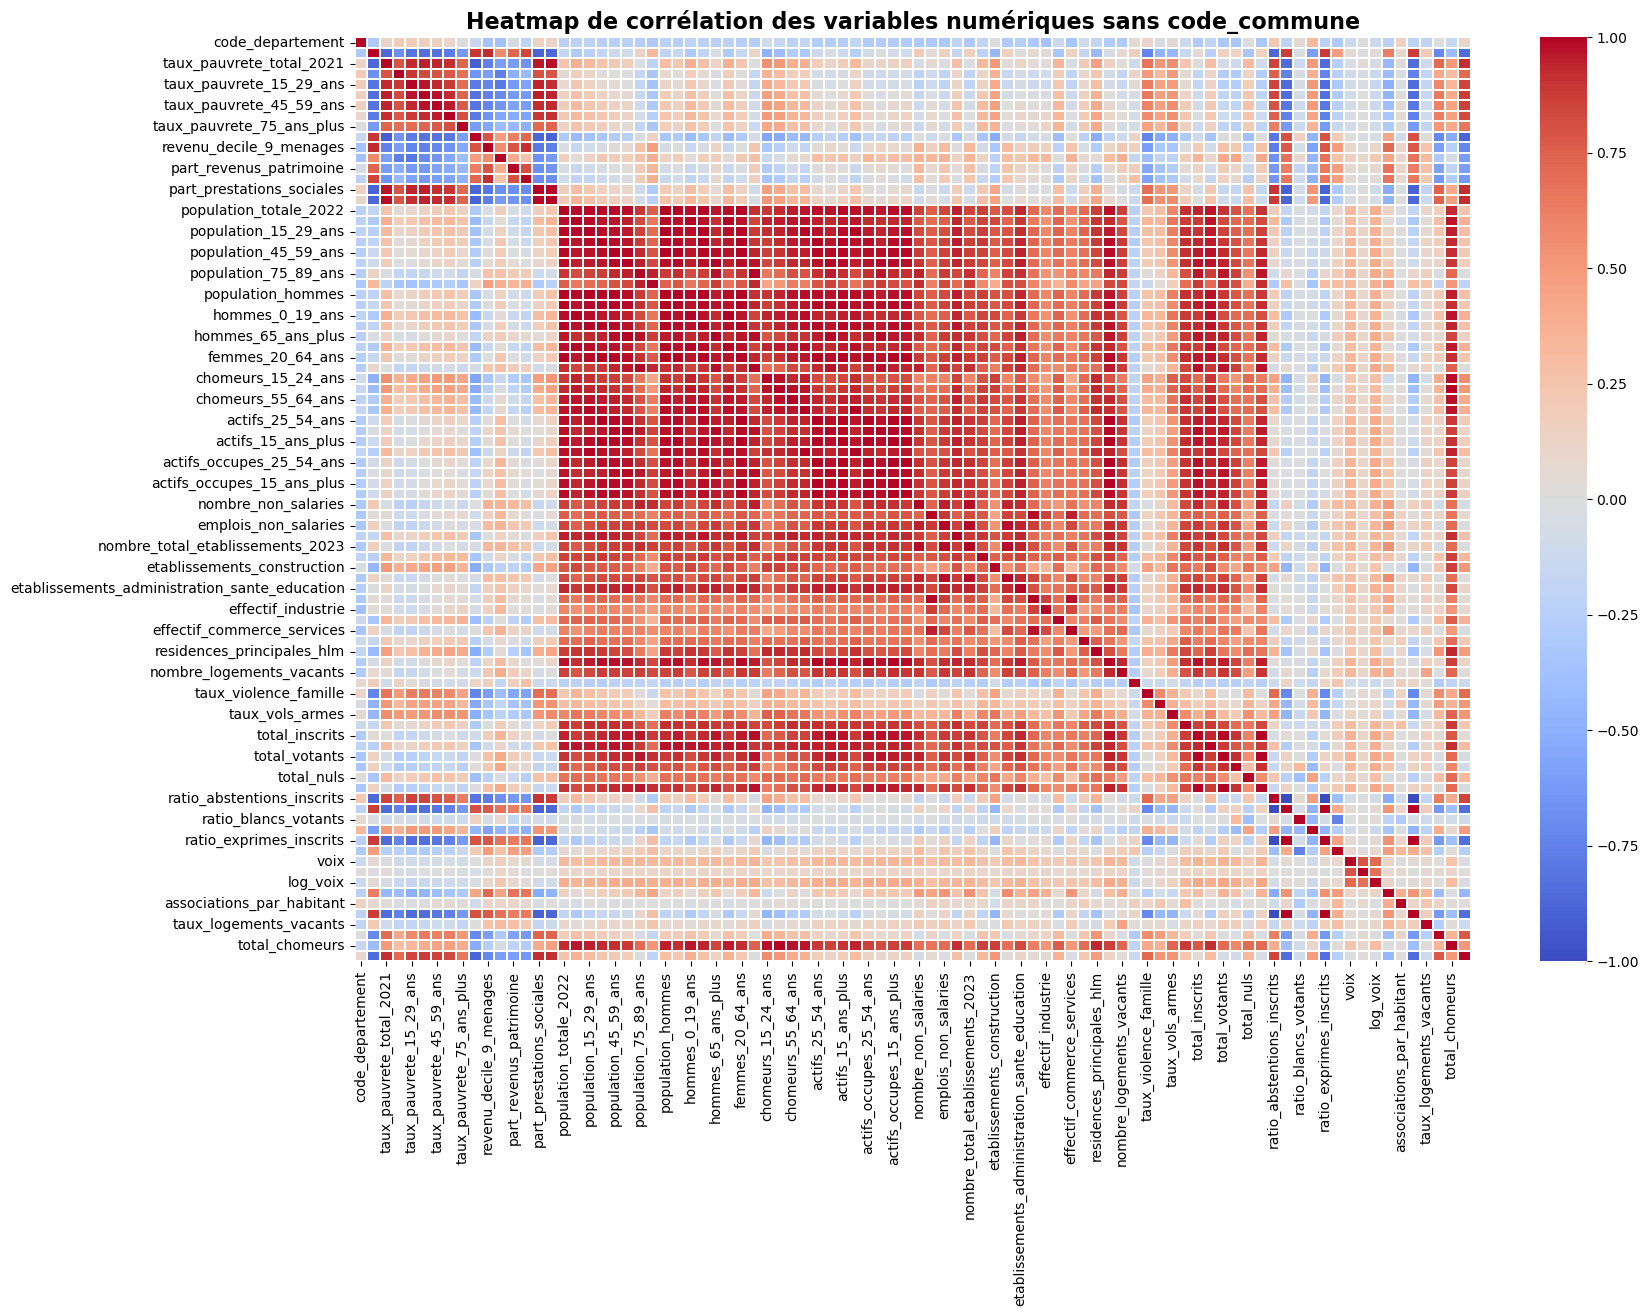

In [28]:
cols_num = df_complet.select_dtypes(include=["int64", "float64"]).copy()

cols_to_exclude = ["code_commune","code_postal"]

cols_num = cols_num.drop(
    columns=cols_to_exclude,
    errors="ignore"
)

print("Nombre de variables numériques :", cols_num.shape[1])

corr_matrix = cols_num.corr()

plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Heatmap de corrélation des variables numériques sans code_commune",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [29]:
corr_target = (
    df_complet
    .select_dtypes(include=["int64", "float64"])
    .corr()["log_voix"]
    .sort_values(ascending=False)
)

pd.set_option("display.max_rows", None)
print(corr_target)

log_voix                                         1.000000
voix                                             0.714093
pourcentage_voix                                 0.684084
total_votants                                    0.430093
total_exprimes                                   0.429891
total_inscrits                                   0.428503
femmes_65_ans_plus                               0.418118
actifs_occupes_55_64_ans                         0.416758
actifs_55_64_ans                                 0.411831
population_75_89_ans                             0.411652
actifs_occupes_25_54_ans                         0.411495
actifs_occupes_15_ans_plus                       0.411272
nombre_salaries                                  0.410081
nombre_total_logements                           0.406875
population_60_74_ans                             0.404721
actifs_25_54_ans                                 0.404042
actifs_15_ans_plus                               0.402869
hommes_65_ans_

In [30]:
corr_target = corr_matrix["log_voix"].sort_values(ascending=False)

print("Top 20 corrélations positives avec log_voix :")
print(corr_target.head(20))

print("\nTop 20 corrélations négatives avec log_voix :")
print(corr_target.tail(20))

Top 20 corrélations positives avec log_voix :
log_voix                      1.000000
voix                          0.714093
pourcentage_voix              0.684084
total_votants                 0.430093
total_exprimes                0.429891
total_inscrits                0.428503
femmes_65_ans_plus            0.418118
actifs_occupes_55_64_ans      0.416758
actifs_55_64_ans              0.411831
population_75_89_ans          0.411652
actifs_occupes_25_54_ans      0.411495
actifs_occupes_15_ans_plus    0.411272
nombre_salaries               0.410081
nombre_total_logements        0.406875
population_60_74_ans          0.404721
actifs_25_54_ans              0.404042
actifs_15_ans_plus            0.402869
hommes_65_ans_plus            0.401818
population_45_59_ans          0.398471
femmes_20_64_ans              0.397436
Name: log_voix, dtype: float64

Top 20 corrélations négatives avec log_voix :
taux_violence_famille         0.035206
revenu_median_menages_2021    0.033664
ratio_blancs_votan

In [31]:
top_positive = (
    corr_target
    .drop("log_voix")
    .sort_values(ascending=False)
    .head(20)
)


top_negative = (
    corr_target
    .drop("log_voix")
    .sort_values(ascending=True)
    .head(20)
)

# Fusion des deux
top_corr_combined = pd.concat([
    top_positive,
    top_negative
])

top_corr_combined = top_corr_combined.sort_values()

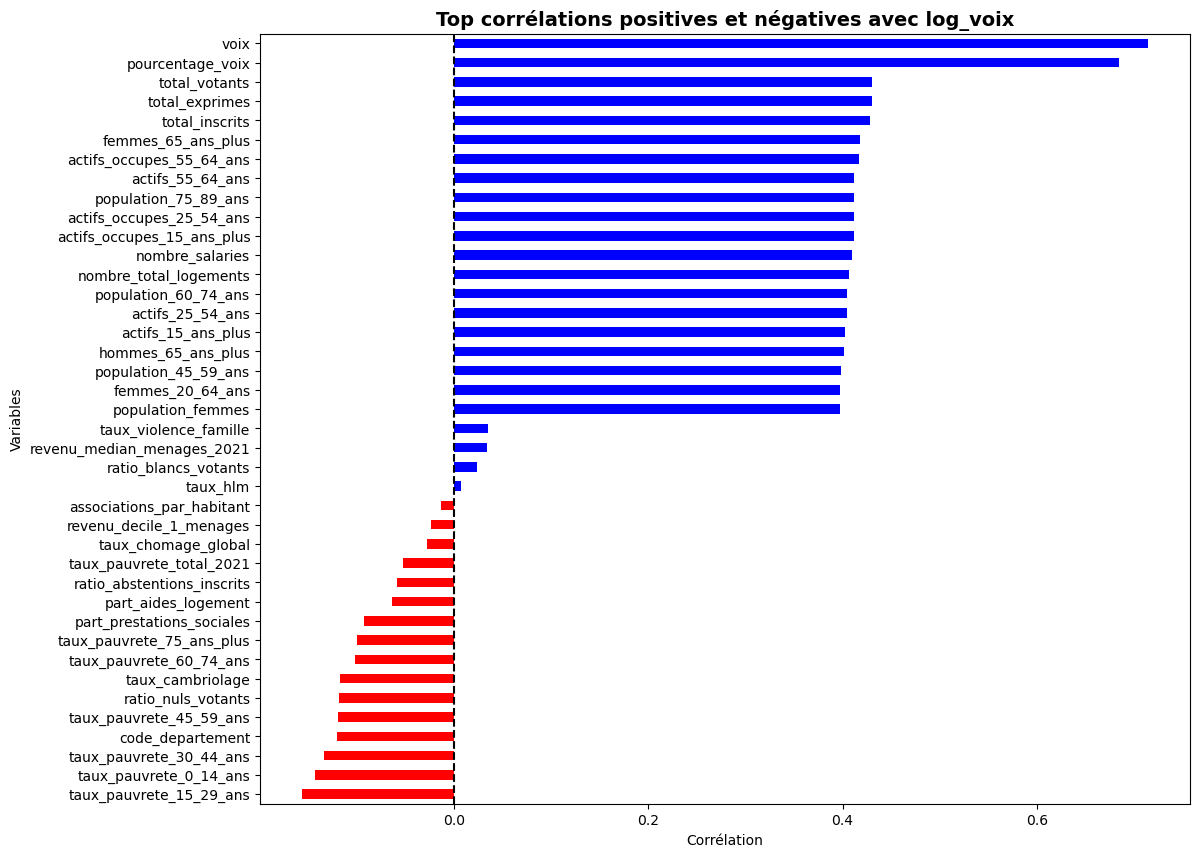

In [32]:
plt.figure(figsize=(12,10))

colors = [
    "red" if val < 0 else "blue"
    for val in top_corr_combined
]

top_corr_combined.plot(
    kind="barh",
    color=colors
)

plt.title(
    "Top corrélations positives et négatives avec log_voix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Corrélation")
plt.ylabel("Variables")

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.show()

# 10. Préparation des données pour le Machine Learning

## 10.1 Définition des features et de la variable cible

In [33]:
selected_features = [

    # ===== DEMOGRAPHIE =====
    "population_totale_2022",
    "population_15_29_ans",
    "population_45_59_ans",
    "population_60_74_ans",

    # ===== ECONOMIE =====
    "revenu_median_menages_2021",
    "nombre_total_etablissements_2023",
    "entreprises_par_habitant",

    # ===== EMPLOI =====
    "taux_chomage_global",

    # ===== SOCIAL =====
    "taux_pauvrete_total_2021",
    "taux_hlm",
    "associations_par_habitant",

    # ===== PARTICIPATION =====
    "participation_reelle",

    # ===== LOGEMENT =====
    "taux_logements_vacants",

    # ===== SECURITE =====
    "taux_cambriolage",

]

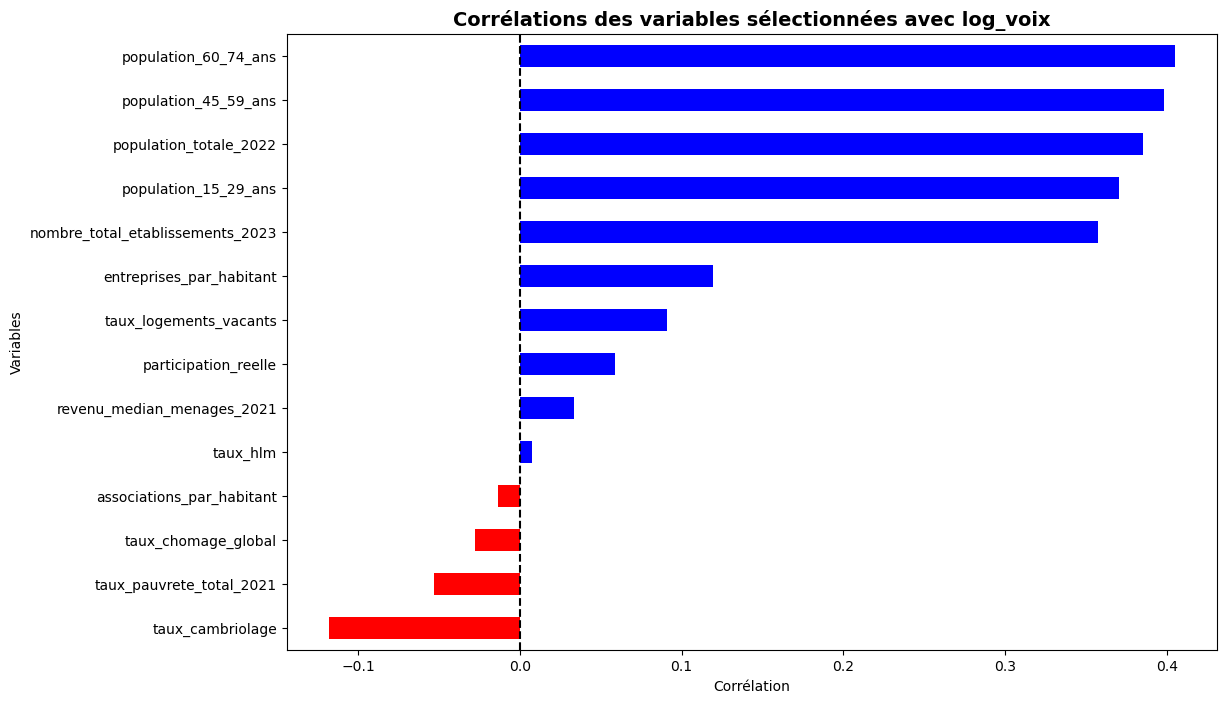

In [34]:
selected_corr = corr_target[selected_features]

selected_corr = selected_corr.sort_values()

plt.figure(figsize=(12,8))

colors = [
    "red" if val < 0 else "blue"
    for val in selected_corr
]

selected_corr.plot(
    kind="barh",
    color=colors
)

plt.title(
    "Corrélations des variables sélectionnées avec log_voix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Corrélation")
plt.ylabel("Variables")

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.show()

In [35]:
features = [
    # ===== CANDIDAT =====
    "nom_complet",

    # ===== DEMOGRAPHIE =====
    "population_totale_2022",
    "population_15_29_ans",
    "population_45_59_ans",
    "population_60_74_ans",

    # ===== ECONOMIE =====
    "revenu_median_menages_2021",
    "nombre_total_etablissements_2023",
    "entreprises_par_habitant",

    # ===== EMPLOI =====
    "taux_chomage_global",

    # ===== SOCIAL =====
    "taux_pauvrete_total_2021",
    "taux_hlm",
    "associations_par_habitant",

    # ===== PARTICIPATION =====
    "participation_reelle",

    # ===== LOGEMENT =====
    "taux_logements_vacants",

    # ===== SECURITE =====
    "taux_cambriolage",
]

target="log_voix"

## Justification du choix des variables sélectionnées

La sélection des variables a été réalisée à partir de deux critères principaux :

- leur corrélation avec la variable cible `log_voix`,
- leur pertinence métier dans l’analyse des comportements électoraux.

L’objectif n’était pas uniquement de conserver les variables les plus corrélées statistiquement, mais également de construire un dataset équilibré représentant différentes dimensions socio-économiques des communes.

Il est également important de noter que la corrélation mesure principalement une relation linéaire simple entre deux variables. Ainsi, une faible corrélation n’implique pas nécessairement qu’une variable soit inutile pour le Machine Learning.

En effet, plusieurs modèles utilisés dans ce projet, notamment :
- Random Forest,
- XGBoost,
- Decision Tree,

sont capables d’apprendre des relations complexes et non linéaires entre les variables explicatives et les comportements électoraux.

Certaines variables présentant une faible corrélation statistique avec `log_voix` peuvent donc rester très pertinentes d’un point de vue prédictif et métier.

### Variables démographiques
Les variables liées à la population (`population_totale_2022`, `population_15_29_ans`, `population_45_59_ans`, `population_60_74_ans`) permettent de représenter la structure démographique des communes.  
Les comportements électoraux pouvant varier selon les catégories d’âge, ces variables constituent des indicateurs importants pour les modèles prédictifs.

### Variables économiques
Les variables économiques (`revenu_median_menages_2021`, `nombre_total_etablissements_2023`, `entreprises_par_habitant`) permettent d’évaluer :
- le niveau de revenu,
- le dynamisme économique,
- l’activité entrepreneuriale des territoires.

Ces éléments peuvent influencer les préférences politiques et les résultats électoraux.

### Variables sociales
Les variables sociales (`taux_pauvrete_total_2021`, `taux_hlm`, `associations_par_habitant`) permettent de représenter :
- la fragilité sociale,
- la structure résidentielle,
- l’engagement citoyen local.

Même si certaines présentent une corrélation statistique faible avec `log_voix`, elles restent importantes d’un point de vue métier et politique.

### Variables liées à l’emploi
Le `taux_chomage_global` constitue un indicateur socio-économique majeur pouvant influencer les comportements électoraux et les dynamiques politiques locales.

### Variables électorales
La variable `participation_reelle` mesure le niveau de mobilisation électorale dans les communes et représente un facteur important dans l’analyse des résultats politiques.

### Variables territoriales et de sécurité
Les variables `taux_logements_vacants` et `taux_cambriolage` permettent de représenter certaines réalités territoriales liées à l’attractivité résidentielle et au contexte sécuritaire local.

### Variable candidat
La variable `nom_complet` a été conservée car l’approche du projet consiste à prédire le nombre de voix obtenu par chaque candidat dans chaque commune.

Les données socio-économiques étant identiques pour tous les candidats d’une même commune, le candidat constitue un facteur différenciant indispensable pour permettre au modèle de distinguer les différentes lignes du dataset.

Ainsi, la sélection finale des variables permet de construire un dataset cohérent, équilibré et adapté à la prédiction électorale par Machine Learning.

## 10.2 Séparation Train/Test par commune

In [36]:
 communes = df_complet["libelle_commune"].unique()

train_communes, test_communes = train_test_split(
communes,
test_size=0.2,
random_state=42
)

train_df = df_complet[
df_complet["libelle_commune"].isin(train_communes)
].copy()

test_df = df_complet[
df_complet["libelle_commune"].isin(test_communes)
].copy()

print("Nombre de communes train :", train_df["libelle_commune"].nunique())
print("Nombre de communes test :", test_df["libelle_commune"].nunique())

print("\nNombre de lignes train :", train_df.shape)
print("Nombre de lignes test :", test_df.shape)

Nombre de communes train : 98
Nombre de communes test : 25

Nombre de lignes train : (1176, 95)
Nombre de lignes test : (300, 95)


## 10.3 Creation de X / y et encodage des variables

In [37]:
X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

print("Avant encodage :")
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("\nAprès encodage :")
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("\nTypes restants dans X_train :")
print(X_train.dtypes.value_counts())

Avant encodage :
X_train : (1176, 15)
X_test : (300, 15)

Après encodage :
X_train : (1176, 26)
X_test : (300, 26)

Types restants dans X_train :
float64    13
bool       12
int64       1
Name: count, dtype: int64


# 11 Modélisation Machine Learning

## 11.1 Définition des modèles

In [38]:
# Dictionnaire des modèles
models = {
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),


    "SVM": SVR(),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
}

In [39]:
models

{'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'SVM': SVR(),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)}

## 11.2 Entraînement et évaluation des modèles

In [40]:
resultats_models = []

for name, model in models.items():

    print("\n==============================")
    print("Modèle :", name)
    print("==============================")

    model.fit(X_train, y_train)

    test_temp = test_df.copy()
    test_temp["log_voix_predites"] = model.predict(X_test)

    pred_winners = test_temp.loc[
        test_temp.groupby("libelle_commune")["log_voix_predites"].idxmax()
    ].copy()

    real_winners_test = df_gagnant[
        df_gagnant["libelle_commune"].isin(test_communes)
    ].copy()

    df_compare = pred_winners.merge(
        real_winners_test,
        on="libelle_commune",
        how="inner",
        suffixes=("_pred", "_reel")
    )

    y_true = df_compare["famille_politique_reel"]
    y_pred = df_compare["famille_politique_pred"]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1-score :", f1)

    print("\nClassification report :")
    print(classification_report(y_true, y_pred, zero_division=0))

    resultats_models.append({
        "Modele": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


Modèle : Decision Tree
Accuracy : 0.88
Precision : 0.8835897435897436
Recall : 0.88
F1-score : 0.8803864734299516

Classification report :
              precision    recall  f1-score   support

      Centre       0.83      0.91      0.87        11
      Gauche       0.92      0.86      0.89        14

    accuracy                           0.88        25
   macro avg       0.88      0.88      0.88        25
weighted avg       0.88      0.88      0.88        25


Modèle : Random Forest
Accuracy : 0.92
Precision : 0.92
Recall : 0.92
F1-score : 0.92

Classification report :
              precision    recall  f1-score   support

      Centre       0.91      0.91      0.91        11
      Gauche       0.93      0.93      0.93        14

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25


Modèle : SVM
Accuracy : 0.56
Precision : 0.5646153846153846
Recall : 0.56
F1-score : 0.561417

In [41]:
## 11.3 Comparaison des performances des modèles

In [42]:
df_resultats_models = pd.DataFrame(resultats_models)

df_resultats_models = df_resultats_models.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n===== COMPARAISON DES MODÈLES =====")
display(df_resultats_models)


===== COMPARAISON DES MODÈLES =====


,Modele,Accuracy,Precision,Recall,F1-score
3,XGBoost,0.96,0.963333,0.96,0.960129
1,Random Forest,0.92,0.920000,0.92,0.920000
0,Decision Tree,0.88,0.883590,0.88,0.880386
2,SVM,0.56,0.564615,0.56,0.561417


## 11.4 Sélection du meilleur modèle

In [43]:
df_resultats_models = df_resultats_models.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

meilleur_modele_nom = df_resultats_models.loc[0, "Modele"]
meilleur_accuracy = df_resultats_models.loc[0, "Accuracy"]

print("Meilleur modèle :", meilleur_modele_nom)
print("Accuracy du meilleur modèle :", round(meilleur_accuracy, 4))

display(df_resultats_models)

Meilleur modèle : XGBoost
Accuracy du meilleur modèle : 0.96


,Modele,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.96,0.963333,0.96,0.960129
1,Random Forest,0.92,0.920000,0.92,0.920000
2,Decision Tree,0.88,0.883590,0.88,0.880386
3,SVM,0.56,0.564615,0.56,0.561417


# 12. Visualisation des résultats Machine Learning

## 12.1 Comparaison des Accuracy des modèles

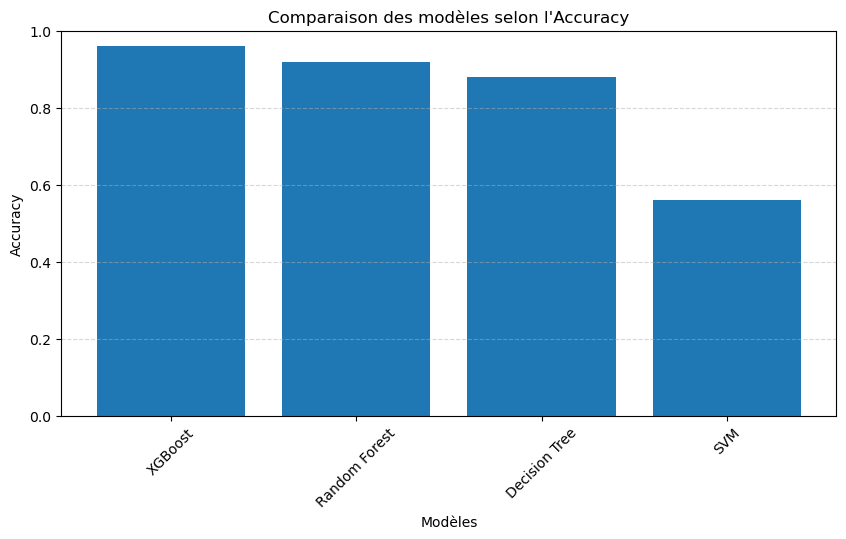

In [44]:
plt.figure(figsize=(10,5))

plt.bar(
    df_resultats_models["Modele"],
    df_resultats_models["Accuracy"]
)

plt.title("Comparaison des modèles selon l'Accuracy")
plt.xlabel("Modèles")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 12.2 Comparaison globale des métriques

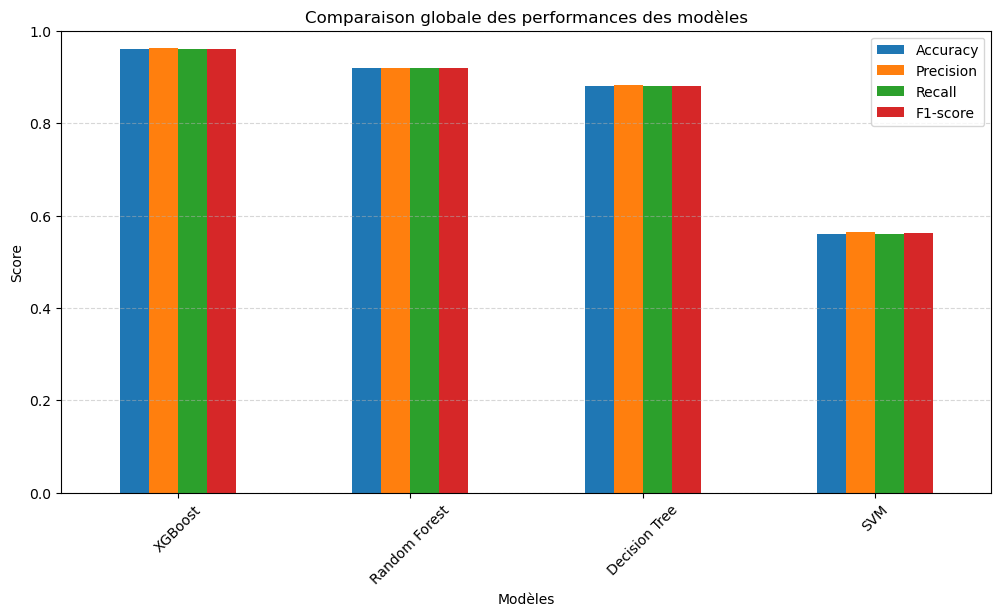

In [45]:
df_resultats_models.set_index("Modele")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparaison globale des performances des modèles")
plt.xlabel("Modèles")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 12.3 Matrice de confusion

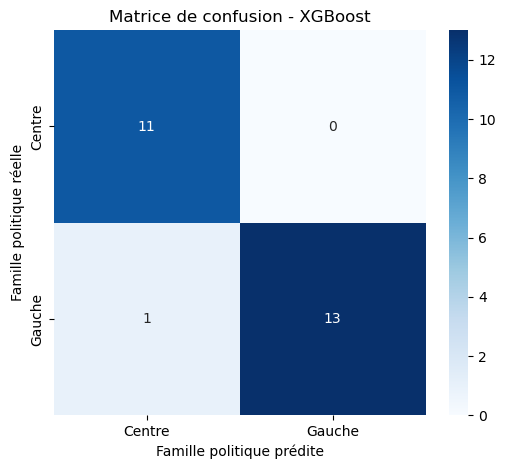

In [46]:
best_model = models[meilleur_modele_nom]

best_model.fit(X_train, y_train)

test_temp = test_df.copy()
test_temp["log_voix_predites"] = best_model.predict(X_test)

pred_winners = test_temp.loc[
    test_temp.groupby("libelle_commune")["log_voix_predites"].idxmax()
].copy()

real_winners_test = df_gagnant[
    df_gagnant["libelle_commune"].isin(test_communes)
].copy()

df_compare_best = pred_winners.merge(
    real_winners_test,
    on="libelle_commune",
    how="inner",
    suffixes=("_pred", "_reel")
)

y_true_best = df_compare_best["famille_politique_reel"]
y_pred_best = df_compare_best["famille_politique_pred"]

cm = confusion_matrix(y_true_best, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_true_best.unique()),
    yticklabels=sorted(y_true_best.unique())
)

plt.title(f"Matrice de confusion - {meilleur_modele_nom}")
plt.xlabel("Famille politique prédite")
plt.ylabel("Famille politique réelle")

plt.show()

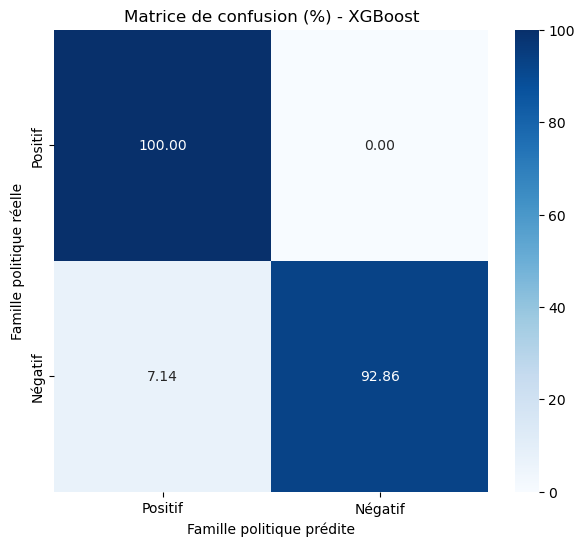

In [47]:

cm = confusion_matrix(
    y_true_best,
    y_pred_best
)

cm_percent = (
    cm.astype("float") /
    cm.sum(axis=1)[:, np.newaxis]
) * 100

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Positif","Négatif"],
    yticklabels=["Positif","Négatif"]

    
)

plt.title(
    f"Matrice de confusion (%) - {meilleur_modele_nom}"
)

plt.xlabel("Famille politique prédite")
plt.ylabel("Famille politique réelle")

plt.show()

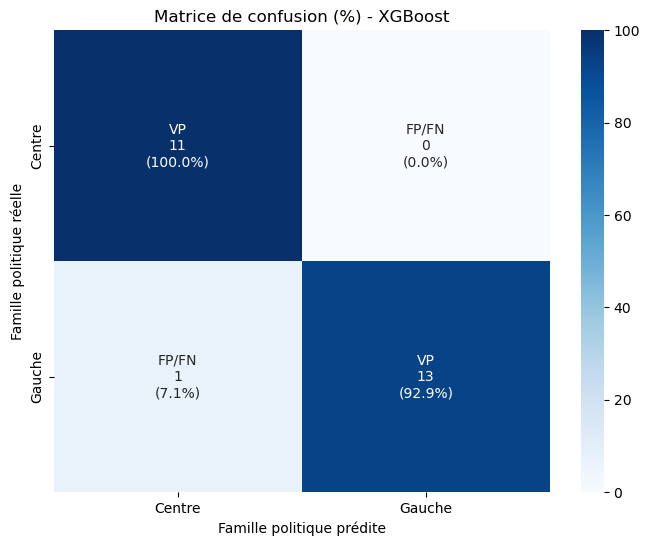

In [48]:
labels = sorted(
    list(
        set(y_true_best) | set(y_pred_best)
    )
)

cm = confusion_matrix(
    y_true_best,
    y_pred_best,
    labels=labels
)

cm_percent = (
    cm.astype("float") /
    cm.sum(axis=1)[:, np.newaxis]
) * 100

annotations = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        valeur = cm[i, j]
        pourcentage = cm_percent[i, j]

        if i == j:
            type_case = "VP"
        else:
            type_case = "FP/FN"

        annotations[i, j] = (
            f"{type_case}\n"
            f"{valeur}\n"
            f"({pourcentage:.1f}%)"
        )

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_percent,
    annot=annotations,
    fmt="",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    f"Matrice de confusion (%) - {meilleur_modele_nom}"
)

plt.xlabel("Famille politique prédite")
plt.ylabel("Famille politique réelle")

plt.show()

## 12.4 Scatter Plot : valeurs réelles vs prédictions

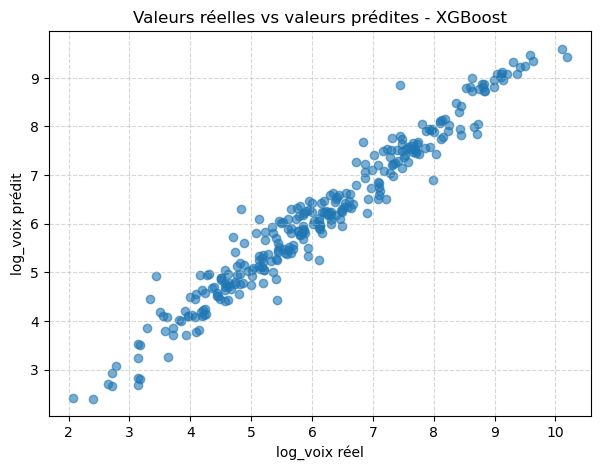

In [49]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    best_model.predict(X_test),
    alpha=0.6
)

plt.title(f"Valeurs réelles vs valeurs prédites - {meilleur_modele_nom}")
plt.xlabel("log_voix réel")
plt.ylabel("log_voix prédit")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [50]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(X_train.columns, "model_columns.pkl")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.
